# AI 231 (MLOps) — Machine Exercise 1
## 3-Layer CNN for MNIST, built from scratch with `einops` / `einsum`

**Author:** Jomar Christian Camposano

Every layer/operation is implemented from **torch tensors + einops/einsum** — no CNN libraries
(`nn.Conv2d`, `F.conv2d`, `nn.MaxPool2d`, `nn.Linear` are all **not** used).

| Operation | Implementation |
|---|---|
| Convolution | `Tensor.unfold` sliding window + `einsum` |
| Max pooling | `einops.reduce(..., 'max')` |
| Flatten | `einops.rearrange` |
| Linear / FC head | `einsum` |
| ReLU, log-softmax, cross-entropy | plain tensor ops |

`torch.autograd` only backprops through the graph, and `torch.optim.Adam` is the optimizer —
neither is a CNN library. Trained for **5 epochs**; test accuracy and a 4×4 sample grid are reported below.


### 0. Setup

In [1]:
# If needed on a fresh HPC env:
# !pip install torch torchvision einops matplotlib
import torch
import torch.optim as optim
from torch import einsum
from einops import rearrange, reduce
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED, EPOCHS, BATCH_SIZE, LR = 0, 5, 128, 1e-3
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda


GPU: NVIDIA A100-SXM4-40GB


### 1. Data
`torchvision` is used **only** to download and normalize MNIST — not for any modeling.

In [2]:
tfm = transforms.Compose([
    transforms.ToTensor(),                       # -> (1, 28, 28) float in [0, 1]
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tfm)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=256, shuffle=False)
print(f"train={len(train_ds)}  test={len(test_ds)}")

train=60000  test=10000


### 2. Layers & operations — from scratch

**Convolution.** `Tensor.unfold` builds a strided sliding-window *view* of shape
`(B, Cin, OH, OW, K, K)`; the multiply-accumulate over `(Cin, K, K)` is one `einsum`:

$$\text{out}[b,o,p,q] = \sum_{c,i,j} \text{patch}[b,c,p,q,i,j]\;\cdot\;W[o,c,i,j] \;+\; \text{bias}[o]$$

In [3]:
def conv2d(x, weight, bias, stride=1):
    # x:(B,Cin,H,W)  weight:(Cout,Cin,K,K)  bias:(Cout,)  -> (B,Cout,OH,OW)
    K = weight.shape[-1]
    patches = x.unfold(2, K, stride).unfold(3, K, stride)   # (B,Cin,OH,OW,K,K)
    out = einsum("b c p q i j, o c i j -> b o p q", patches, weight)
    return out + rearrange(bias, "o -> 1 o 1 1")

def relu(x):
    return torch.clamp(x, min=0.0)

def maxpool2d(x, k=2):                                       # non-overlapping max pool
    H, W = x.shape[-2], x.shape[-1]                          # drop remainder (floor),
    x = x[..., :H - H % k, :W - W % k]                       # matches ceil_mode=False
    return reduce(x, "b c (h ph) (w pw) -> b c h w", "max", ph=k, pw=k)

def linear(x, weight, bias):                                # x:(B,I) weight:(O,I)
    return einsum("b i, o i -> b o", x, weight) + bias

def log_softmax(logits):
    z = logits - logits.max(dim=1, keepdim=True).values     # stability
    return z - torch.log(torch.exp(z).sum(dim=1, keepdim=True))

def cross_entropy(logits, targets):
    logp = log_softmax(logits)
    nll = -logp[torch.arange(logits.shape[0], device=logits.device), targets]
    return nll.mean()

### 3. Model — 3 conv layers + linear head

```
28x28 --conv1(1->8,3x3)--> 26 --pool--> 13
      --conv2(8->16,3x3)-> 11 --pool--> 5
      --conv3(16->32,3x3)-> 3   --flatten(288)--> linear --> 10
```

In [4]:
def he_init(shape, fan_in):
    return torch.randn(shape, device=device) * (2.0 / fan_in) ** 0.5

class ScratchCNN:
    def __init__(self):
        self.w1 = he_init((8, 1, 3, 3),  1*3*3).requires_grad_()
        self.b1 = torch.zeros(8,  device=device, requires_grad=True)
        self.w2 = he_init((16, 8, 3, 3), 8*3*3).requires_grad_()
        self.b2 = torch.zeros(16, device=device, requires_grad=True)
        self.w3 = he_init((32, 16, 3, 3), 16*3*3).requires_grad_()
        self.b3 = torch.zeros(32, device=device, requires_grad=True)
        self.wfc = he_init((10, 32*3*3), 32*3*3).requires_grad_()
        self.bfc = torch.zeros(10, device=device, requires_grad=True)

    def parameters(self):
        return [self.w1, self.b1, self.w2, self.b2,
                self.w3, self.b3, self.wfc, self.bfc]

    def forward(self, x):
        x = maxpool2d(relu(conv2d(x, self.w1, self.b1)))   # (B,8,13,13)
        x = maxpool2d(relu(conv2d(x, self.w2, self.b2)))   # (B,16,5,5)
        x = relu(conv2d(x, self.w3, self.b3))              # (B,32,3,3)
        x = rearrange(x, "b c h w -> b (c h w)")           # (B,288)
        return linear(x, self.wfc, self.bfc)               # (B,10)

    __call__ = forward

model = ScratchCNN()
n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable params: {n_params:,}")

Total trainable params: 8,778


### 4. Train for 5 epochs

In [5]:
@torch.no_grad()
def evaluate(model, loader):
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
    return correct / total

opt = optim.Adam(model.parameters(), lr=LR)
for epoch in range(1, EPOCHS + 1):
    running = seen = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = cross_entropy(model(imgs), labels)
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * imgs.size(0); seen += imgs.size(0)
    acc = evaluate(model, test_loader)
    print(f"Epoch {epoch}/{EPOCHS}  train_loss={running/seen:.4f}  test_acc={acc*100:.2f}%")

Epoch 1/5  train_loss=0.4395  test_acc=95.77%


Epoch 2/5  train_loss=0.1142  test_acc=97.57%


Epoch 3/5  train_loss=0.0769  test_acc=97.66%


Epoch 4/5  train_loss=0.0628  test_acc=98.04%


Epoch 5/5  train_loss=0.0521  test_acc=98.01%


### 5. Final test-split accuracy

In [6]:
final_acc = evaluate(model, test_loader)
print(f"FINAL TEST ACCURACY: {final_acc*100:.2f}%")

FINAL TEST ACCURACY: 98.01%


### 6. Sample 16 test images — 4×4 grid with ground truth & prediction

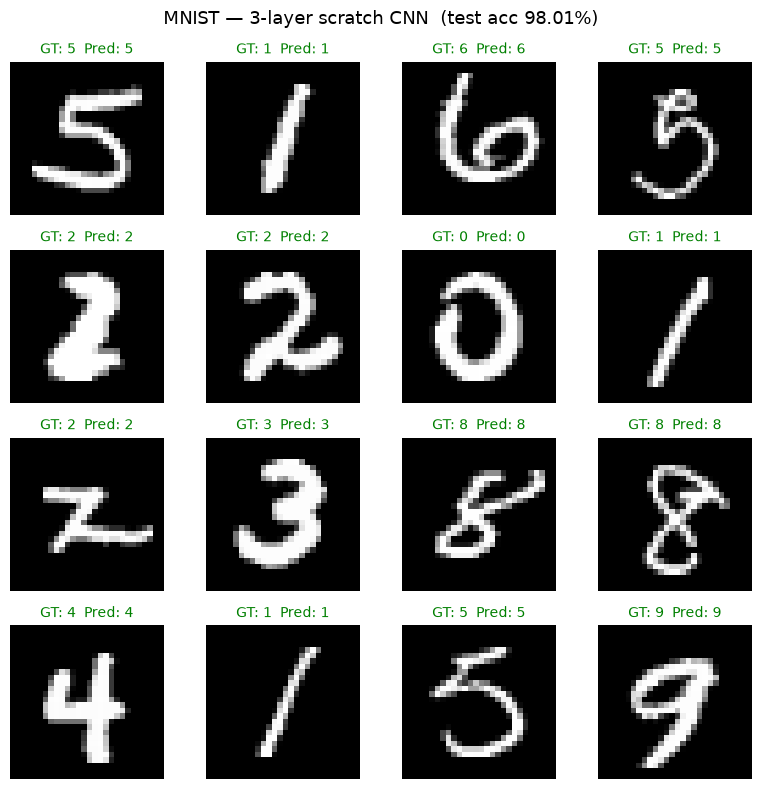

In [7]:
sample_loader = torch.utils.data.DataLoader(test_ds, batch_size=16, shuffle=True)
imgs, labels = next(iter(sample_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu()

disp = imgs * 0.3081 + 0.1307   # undo Normalize for display

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(disp[i, 0], cmap="gray")
    ok = labels[i].item() == preds[i].item()
    ax.set_title(f"GT: {labels[i].item()}  Pred: {preds[i].item()}",
                 color="green" if ok else "red", fontsize=10)
    ax.axis("off")
fig.suptitle(f"MNIST — 3-layer scratch CNN  (test acc {final_acc*100:.2f}%)", fontsize=13)
fig.tight_layout()
fig.savefig("sample_predictions.png", dpi=120, bbox_inches="tight")
plt.show()